In [ ]:
import sys
sys.path.insert(0, '.')

import numpy as np
import matplotlib.pyplot as plt
import loadmat as lm
import stepwisefit
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1
## 1.1

In [ ]:
data = lm.loadmat('dataP300.mat')['data']
training = data['training']

# shape: (nbSamples, nbChannels, nbResponses, nbSequences)
infrequent = training['infrequent']
frequent   = training['frequent']
testing    = data['testing']

fs = 240  # sampling rate in Hz
electrodes = {0: 'Fz', 1: 'C4', 2: 'Cz', 3: 'C3', 4: 'Pz', 5: 'P3', 6: 'P4', 7: 'Oz'}

print('infrequent:', infrequent.shape)
print('frequent:  ', frequent.shape)
print('testing:   ', testing.shape)

infrequent: (500, 8, 24, 15)
frequent:   (500, 8, 120, 15)
testing:    (500, 8, 48, 15)


## 1.2

In [ ]:
def extract_features(data):
    # Average over sequences
    features = data.mean(axis=3)
    # (nbResponses, nbSamples, nbChannels)
    features = features.transpose(2,0,1)
    # (nbResponses, nbSamples * nbChannels)
    features = features.reshape(len(features), -1)
    return features

# Build feature vectors
X_infreq = extract_features(infrequent)
X_freq = extract_features(frequent)

# Training features
X = np.concatenate([X_infreq, X_freq], axis=0)
y = np.concatenate([np.ones(X_infreq.shape[0]), np.zeros(X_freq.shape[0])], axis=0)

# 2
## 2.1

In [ ]:
def plot_class_separation(scores, y, xlabel, title):
    fig, ax = plt.subplots(figsize=(8, 3))
    ax.hist(scores[y == 1], bins=15, alpha=0.6, color='tomato',    label='infrequent (P300)')
    ax.hist(scores[y == 0], bins=15, alpha=0.6, color='steelblue', label='frequent')
    ax.axvline(0, color='black', lw=1.2, ls='--', label='decision boundary')
    ax.set_xlabel(xlabel)
    ax.set_title(title)
    ax.legend()
    ax.spines[['top', 'right']].set_visible(False)
    plt.tight_layout()
    plt.show()

def fit_lda(X, y):
    # Fit & return a LDA model
    return LinearDiscriminantAnalysis().fit(X, y)

def fit_logreg(X, y):
    # Fit & return a regression model
    _, _, _, inmodel, _, _, _ = stepwisefit.stepwisefit(X, y)
    reg = LogisticRegression(max_iter=1000).fit(X[:, inmodel], y)
    return reg, inmodel

Training accuracy: 100.00%


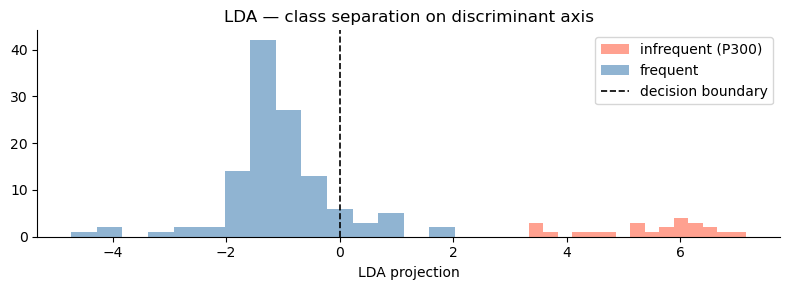

In [ ]:
lda = fit_lda(X, y)
print(f'Training accuracy: {(lda.predict(X) == y).mean():.2%}')
plot_class_separation(lda.transform(X).ravel(), y, 'LDA projection', 'LDA — class separation on discriminant axis')

## 2.2

Features selected: 10 / 4000
Training accuracy: 93.06%


/Users/Alex/Documents/Studium/Master KI/SS 26/Brain-Machine-Interfacing/exercise_2/stepwisefit.py:173: RuntimeWarning: invalid value encountered in divide
  MSexplained = np.divide(SStotal - SSresid, df0)


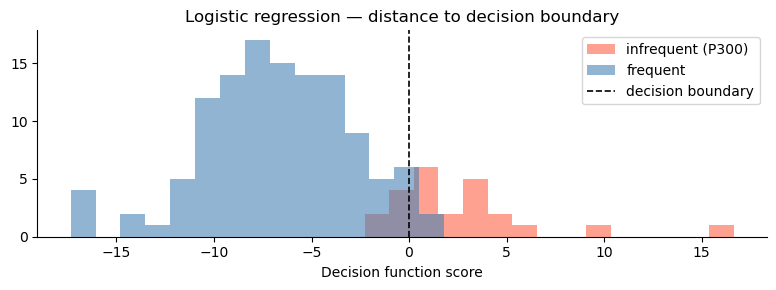

In [ ]:
reg, inmodel = fit_logreg(X, y)
print(f'Features selected: {inmodel.sum()} / {X.shape[1]}')
print(f'Training accuracy: {(reg.predict(X[:, inmodel]) == y).mean():.2%}')
plot_class_separation(reg.decision_function(X[:, inmodel]), y, 'Decision function score', 'Logistic regression — distance to decision boundary')

## 2.3

In [ ]:
# Setup k-fold cross-validation
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

lda_scores = []
reg_scores = []

# Train on all splits
for train_idx, test_idx in skf.split(X, y):
    X_train, X_test = X[train_idx], X[test_idx]
    y_train, y_test = y[train_idx], y[test_idx]

    lda_cv = fit_lda(X_train, y_train)
    lda_scores.append((lda_cv.predict(X_test) == y_test).mean())

    reg_cv, inmodel_cv = fit_logreg(X_train, y_train)
    reg_scores.append((reg_cv.predict(X_test[:, inmodel_cv]) == y_test).mean())

lda_scores = np.array(lda_scores)
reg_scores = np.array(reg_scores)

print(f'LDA               — mean: {lda_scores.mean():.2%}  std: {lda_scores.std():.2%}  per fold: {np.round(lda_scores, 3)}')
print(f'Stepwise + LogReg — mean: {reg_scores.mean():.2%}  std: {reg_scores.std():.2%}  per fold: {np.round(reg_scores, 3)}')

LDA               — mean: 72.91%  std: 6.72%  per fold: [0.862 0.69  0.69  0.69  0.714]
Stepwise + LogReg — mean: 77.78%  std: 5.57%  per fold: [0.862 0.69  0.759 0.793 0.786]


/Users/Alex/Documents/Studium/Master KI/SS 26/Brain-Machine-Interfacing/exercise_2/stepwisefit.py:173: RuntimeWarning: invalid value encountered in divide
  MSexplained = np.divide(SStotal - SSresid, df0)


# 3

In [ ]:
# From the slides
letter_mat = np.array([
    ['A', 'B', 'C', 'D', 'E', 'F'],
    ['G', 'H', 'I', 'J', 'K', 'L'],
    ['M', 'N', 'O', 'P', 'Q', 'R'],
    ['S', 'T', 'U', 'V', 'W', 'X'],
    ['Y', 'Z', '1', '2', '3', '4'],
    ['5', '6', '7', '8', '9', '_'],
])

X_test = extract_features(testing)

# Based on nbResponses
n_letters = 4
n_flashes = 12

predicted_lda = []
predicted_reg = []

for i in range(n_letters):
    x = X_test[i * n_flashes:(i + 1) * n_flashes]

    # Prediction according to LDA
    scores_lda = lda.decision_function(x)
    row_lda = scores_lda[:6].argmax()
    col_lda = scores_lda[6:].argmax()
    predicted_lda.append(letter_mat[row_lda, col_lda])

    # Prediction based on regression
    scores_reg = reg.decision_function(x[:, inmodel])
    row_reg = scores_reg[:6].argmax()
    col_reg = scores_reg[6:].argmax()
    predicted_reg.append(letter_mat[row_reg, col_reg])

print('LDA prediction:      ', ''.join(predicted_lda))
print('LogReg prediction:   ', ''.join(predicted_reg))

LDA prediction:       89YJ
LogReg prediction:    AKZ8
